In [2]:
from geostat_isoscapes_tools import utils, geostat_utils as gutils, plot_utils as putils
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd 

sns.set_style('dark')

In [3]:
countries = None # ['China']
itrace_xrds = gutils.preprocessed_itrace_data(include_snow=True, 
                                            countries=countries, 
                                            P = True,
                                            format = 'xr')

loading itrace files
   setting regular temporal resolution to 31.0 days
   bins of width=31.0 days (0.0 years)
  Loading files for total precipitation info


### **Detailed procedure for a single time step**

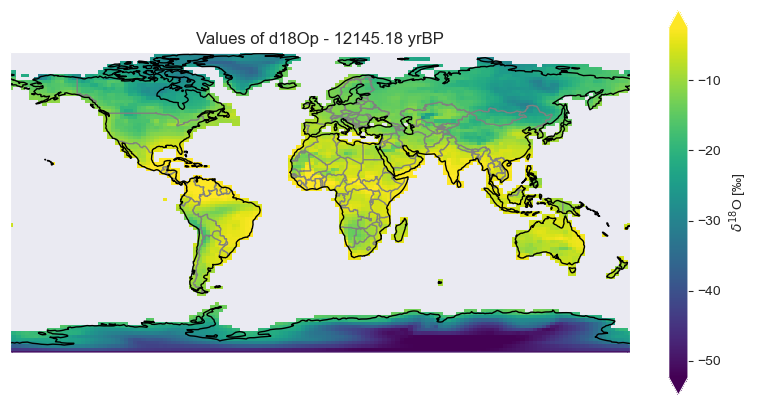

In [23]:
time=itrace_xrds['time'].values[-3000]#-3000

fig,ax = putils.plot_isoscape_latlon_platecarree(itrace_xrds.sel(time=time).d18Op,time=f'{utils.get_yrBP_from_itrace_time(time):.2f} yrBP',countries_borders=True) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
plt.show() 
# Compute Variogram
# V = skg.Variogram(coords_proj, vals_s, n_lags=20, maxlag='median', model='spherical', use_nugget=True, normalize=False)
# ref_bins = V.bins
#
df=itrace_xrds.sel(time=time).to_dataframe().reset_index().dropna(subset=['d18Op','P']) # type:ignore
df['x'], df['y'] = gutils.project_coords(df['lon'].values, df['lat'].values, epsg="EPSG:3857")


#### **Variogram on raw data**

First, let us see whether the data needs to be detrended or is already stationary. 

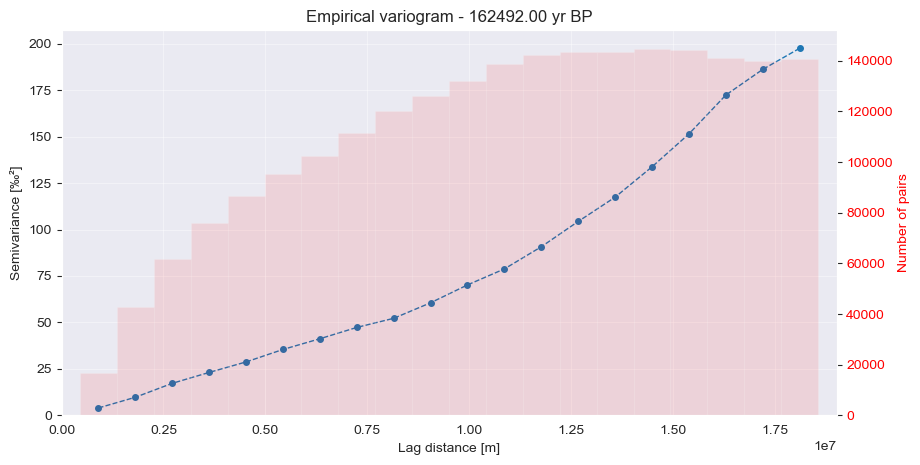

In [24]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend=None,
                                maxlag='median',
                                nlags=20,
                                return_Variogram_object=True,
                                #model='spherical+gaussian'
                                )
ref_bins = V.bins

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{time:.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                #    plot_model=False,
                                                #    model_name=V._model_name,
                                                #    model_fct=V.fitted_model
                                                   ) #type:ignore
plt.show()

The variogram clearly has no sill, this means the data is non stationary and trends need to be removed.
We can try to fit a plane to the data in order to remove a linear drift, if any.

#### **Trend modelled as a simple plane**

r^2 of the trend model (plane) is: 0.22203166446777123


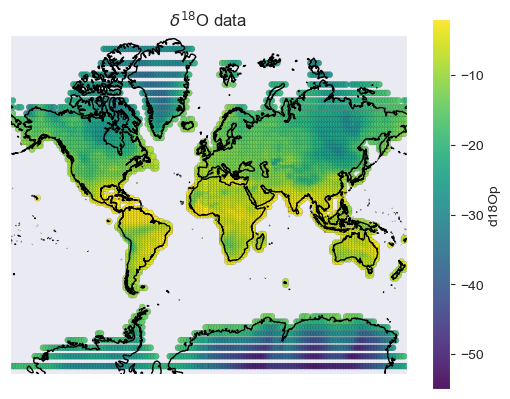

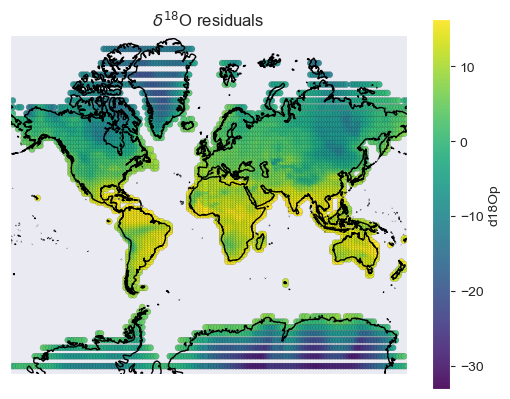

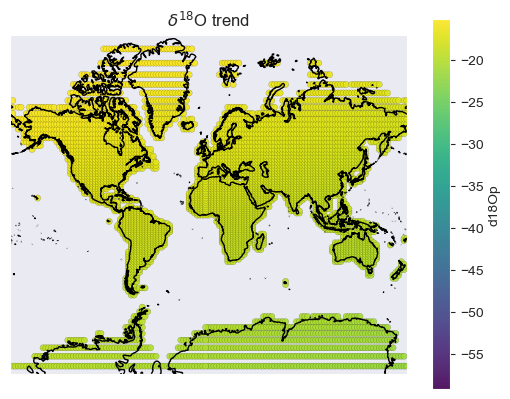

In [25]:
# Visualize the trend found by fitting a plane to the data :
vals = df['d18Op'].values
XY = np.column_stack((df['x'], df['y']))
resid = gutils.detrend_data_plane(XY,vals)

# Rsquare:
sst = np.sum((vals - np.mean(vals))**2)
ssr = np.sum(resid**2)
r2 = 1 - ssr / sst
print('r^2 of the trend model (plane) is:', r2)

fig,ax = putils.plot_projected_data(df[['x','y']].values,vals) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show()
 
fig,ax = putils.plot_projected_data(df[['x','y']].values,resid) # type:ignore
ax.set_title(r'$\delta^{18}$O residuals')
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
plt.show() 

fig,ax = putils.plot_projected_data(df[['x','y']].values,vals-resid) # type:ignore
ax.set_title(r'$\delta^{18}$O trend')
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
plt.show() 

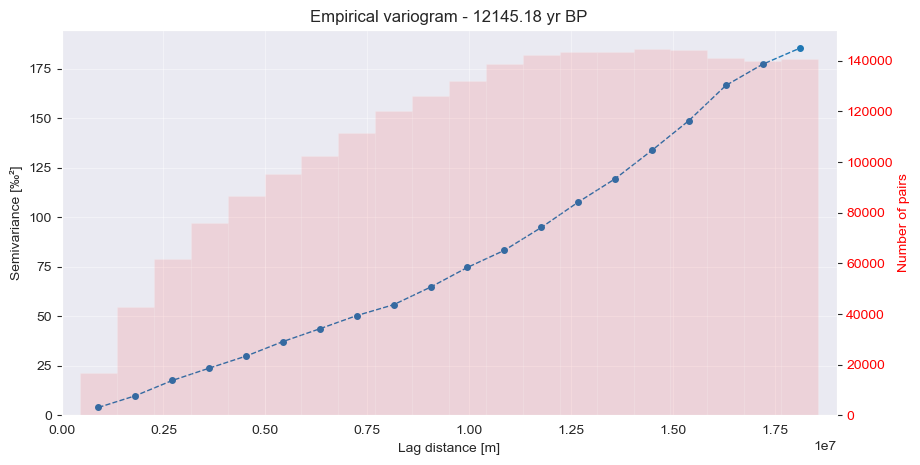

In [26]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='plane',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical'
                                )

parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=False,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()

The linear plane fitted explained only <50% variance of the data, and unfortunately our data seems to have more complex trends than a linear drift, which is uninformed of the physics.

Physically, a known trend in delta18O values is the trend linked to the latitude : going away from tropical latitudes is correlate to a decrease in the delta 18O values.

Hence, we can try to fit and remove a multilinear trend model based on the predictor 'latitude' and 'latitude squared'

#### **Physically informed multilinear trend (multilinear regression)**

##### Latitude 

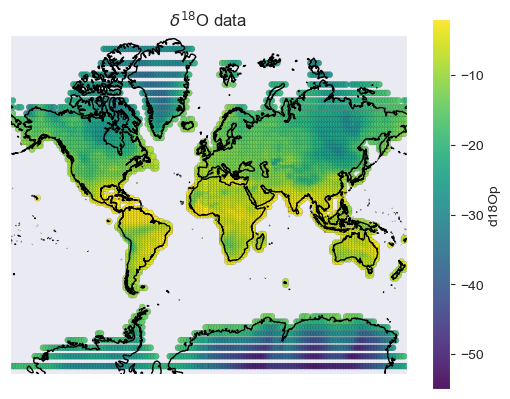

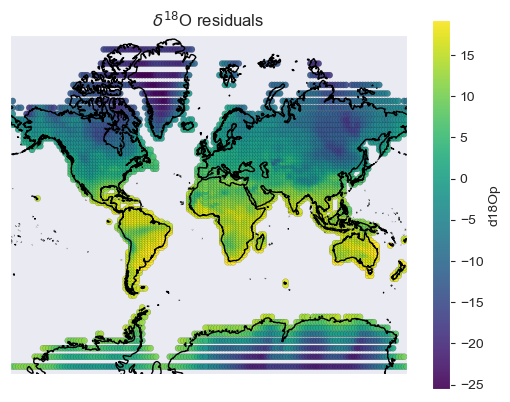

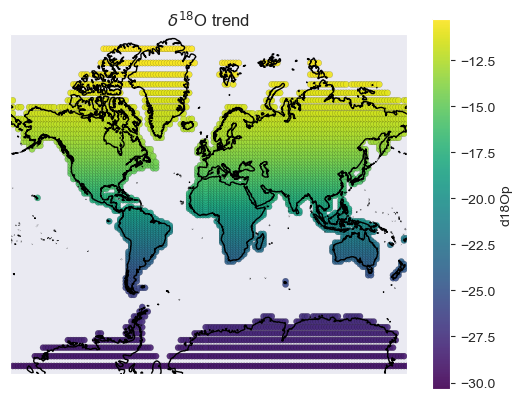

R2= 0.2441532242907849


,name,beta,std_error,p_value
0,intercept,-19.862699,0.156107,0.0
1,lat,0.116491,0.002683,0.0


In [27]:
detrended_df, results_dict = gutils.detrend_multiple_linear_regression(df,spec='lat')

fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

res_df = gutils.multiple_linear_result_dict_to_df(result_dict=results_dict)

print('R2=',results_dict['r2'])
res_df

-> detrending with multiple linear regression, R2 is 0.687 detailed metrics are :
         name      beta  std_error       p_value
0  intercept  2.827926   0.304933  3.332801e-20
1      |lat| -0.428680   0.005279  0.000000e+00


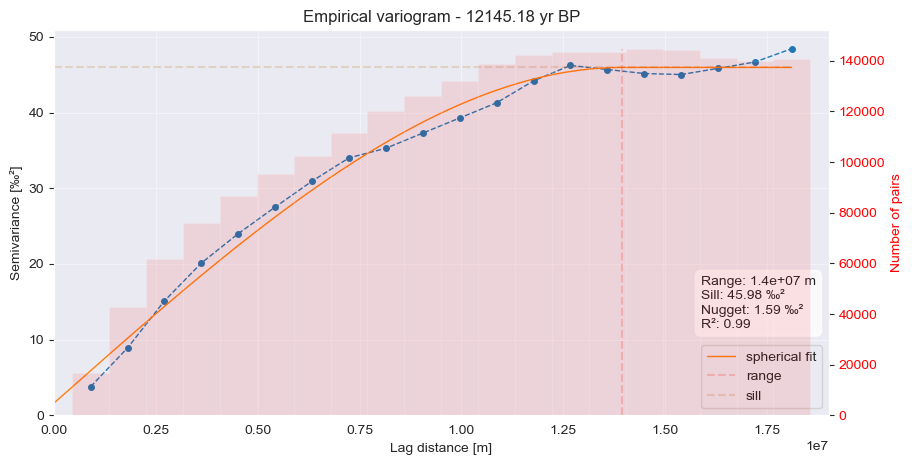

In [28]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multiple_linear_lat_abs',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical'
                                )

parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()

This time, we explained up to 85% (depending on the time chosen) of the variance. Let us see whether other known trends can be retrieved in the data : elevation for instance.

##### Elevation

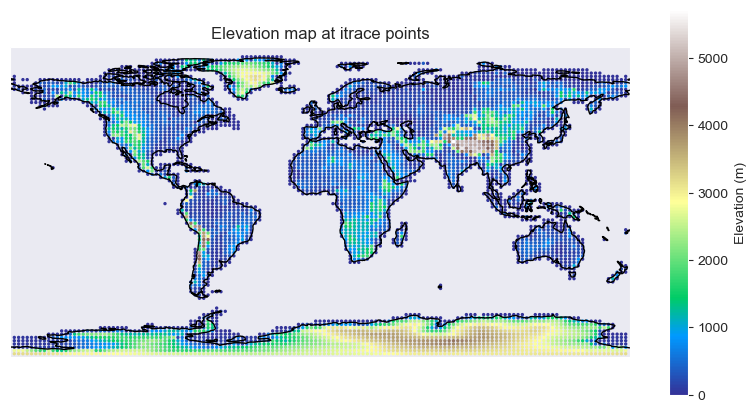

In [29]:
# Inerpolate (bilinear) a DEM at itrace points (ETOPO for instance)
df = gutils.interpolate_dem_at_latlon_points(df)
# now our df has a column 'elevation'
# plot elevation map 
fig,ax = putils.plot_elevation_map(df,countries_borders=False) # type:ignore
ax.set_title('Elevation map at itrace points')
plt.show()  

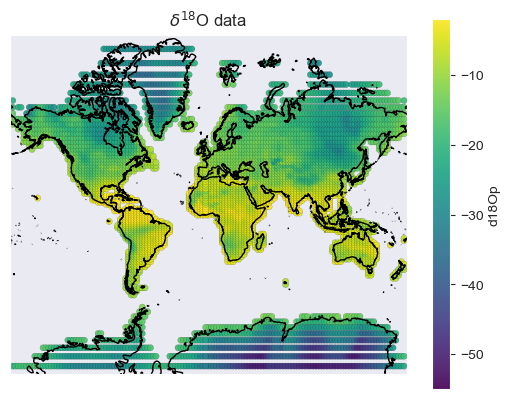

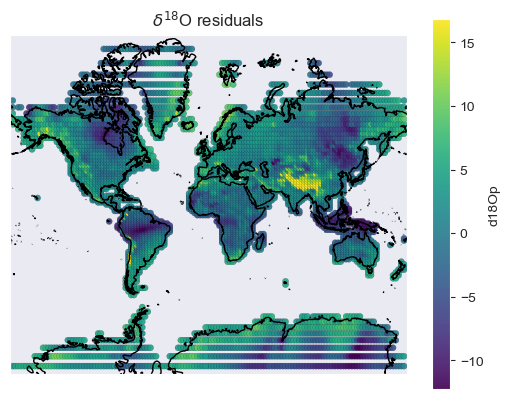

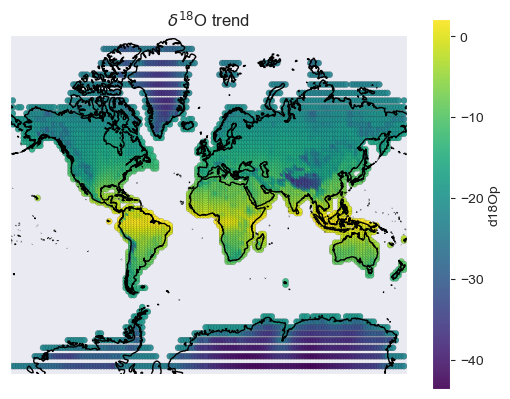

R2= 0.8471478734085355


,name,beta,std_error,p_value,vif,partial r2
0,intercept,2.568179,0.148507,2.435377e-65,<NA>,<NA>
1,|lat|,-0.332047,0.002798,0.000000e+00,1.868214,0.379202
2,elevation,-0.005133,0.000065,0.000000e+00,1.868214,0.166362


In [30]:
# Now let us fit our trend model including this feature
detrended_df, results_dict = gutils.detrend_multiple_linear_regression(df,spec='ele_lat_abs')

fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

res_df = gutils.multiple_linear_result_dict_to_df(result_dict=results_dict)

print('R2=',results_dict['r2'])
res_df

-> detrending with multiple linear regression, R2 is 0.836 detailed metrics are :
         name      beta  std_error       p_value       vif partial r2
0  intercept  2.366209   0.204784  3.028804e-30      <NA>       <NA>
1      |lat| -0.329691   0.003895  0.000000e+00  1.831586   0.391067
2  elevation -0.004919   0.000091  0.000000e+00  1.831586   0.160186


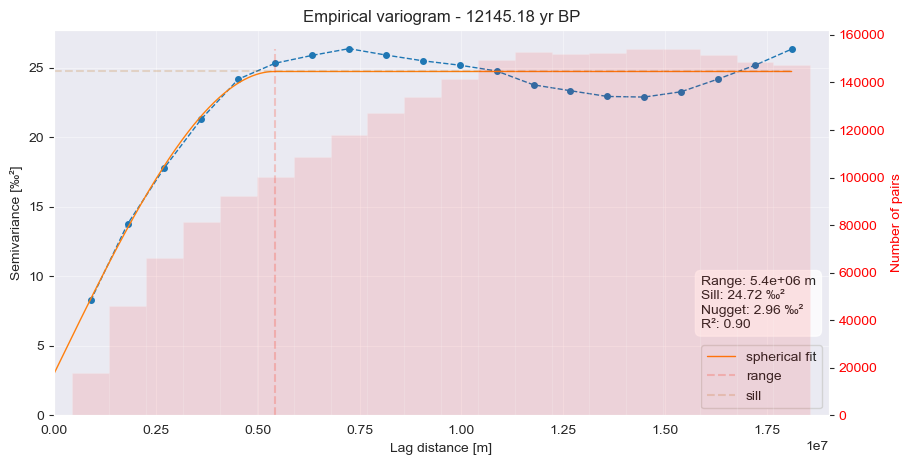

In [32]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multiple_linear_ele_lat_abs',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical'
                                )

parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()

We clearly see the trend linked to altitude in the Himalayas or the Rocky mountains, and gained a few percents of variance explanation.

Now, let us finally introduce the distance to the coast as predictor in our multilinear trend model. This is supposed to enable to capture the continental effect : decrease in delta18O values as the distance to the coast increases. 

##### Distance to the coast

In [33]:
df = gutils.compute_distance_to_coast(
    df,
    coast_shp_path="../data/shapefiles/ne_10m_coastline/ne_10m_coastline.shp"
)

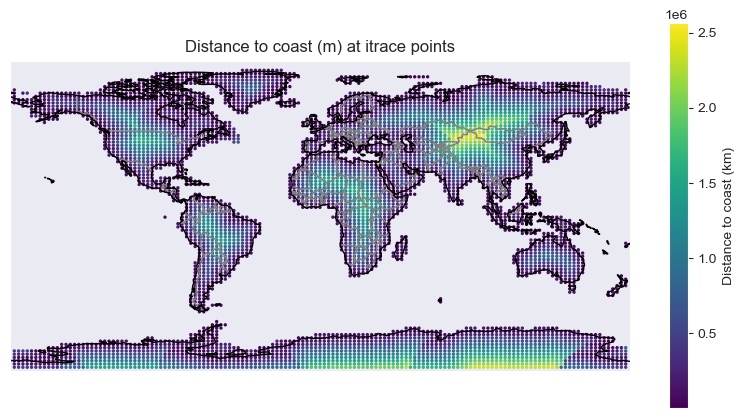

In [34]:
# df.loc[df['dist_coast_m']>2700000,'dist_coast_m']=pd.NA
fig,ax = putils.plot_dist_to_coast_map(df,countries_borders=True) # type:ignore
ax.set_title('Distance to coast (m) at itrace points')
plt.show()

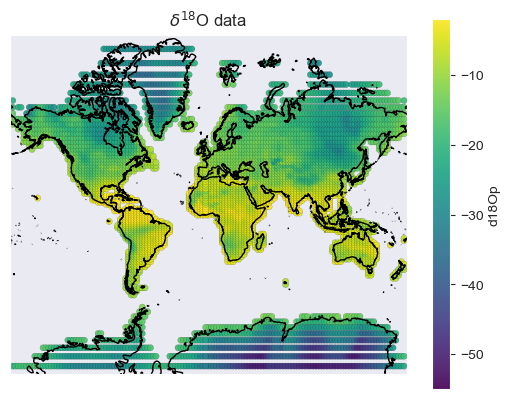

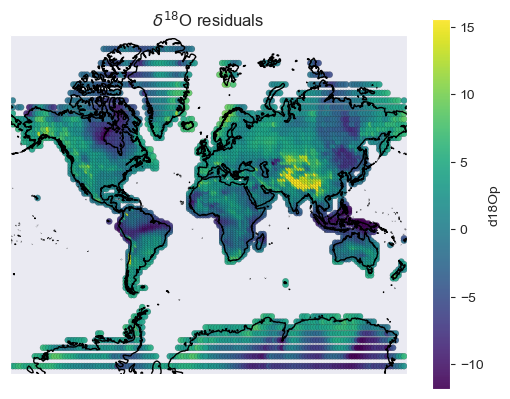

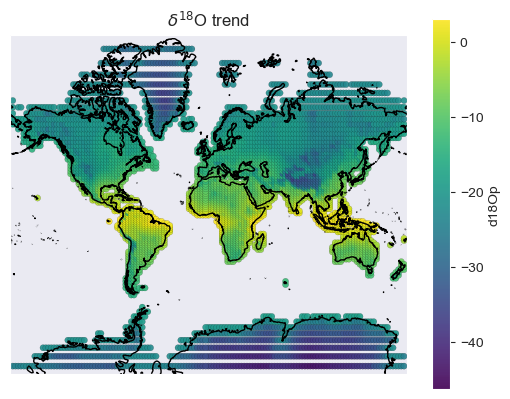

R2= 0.8627982315882883


,name,beta,std_error,p_value,vif,partial r2
0,intercept,3.850554,1.494632e-01,1.631572e-138,<NA>,<NA>
1,|lat|,-0.339628,2.667534e-03,0.000000e+00,2.029516,0.391767
2,elevation,-0.004186,7.219364e-05,0.000000e+00,2.488608,0.081236
3,dist_coast_m,-0.000004,1.399629e-07,2.290817e-135,2.213,0.01565


In [35]:
detrended_df, results_dict = gutils.detrend_multiple_linear_regression(df,spec='ele_D_lat_abs',D_col='dist_coast_m')

fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

res_df = gutils.multiple_linear_result_dict_to_df(result_dict=results_dict)

print('R2=',results_dict['r2'])

res_df

-> detrending with multiple linear regression, R2 is 0.851 detailed metrics are :
            name      beta     std_error        p_value       vif partial r2
0     intercept  3.622681  2.084845e-01   1.638547e-64      <NA>       <NA>
1         |lat| -0.337584  3.743243e-03   0.000000e+00  1.985041    0.40389
2     elevation -0.004050  1.001922e-04  1.509755e-285  2.407078   0.081153
3  dist_coast_m -0.000003  1.936622e-07   1.200681e-63  2.129429   0.014777


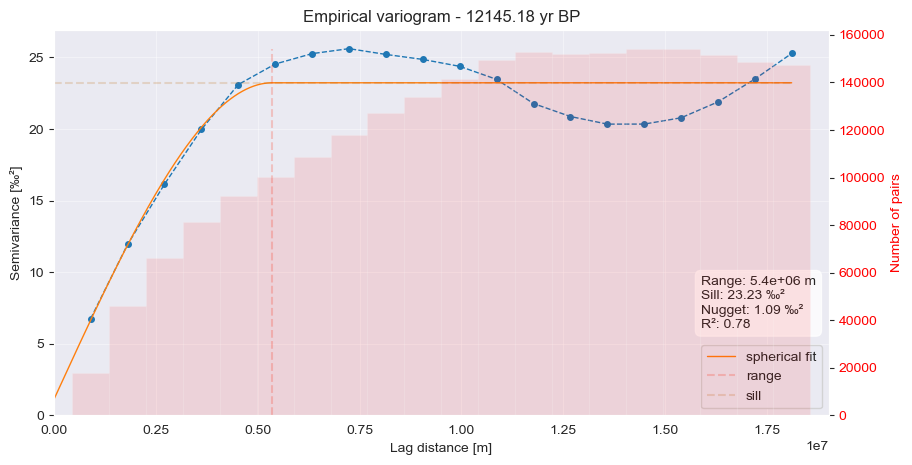

In [36]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multiple_linear_ele_lat_abs_D',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical'
                                )
parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()

##### Precipiation amount

Some of the unexplained variance may be explained by the monthly mean precipitation and monthly mean temperature at each location.

In [41]:
# fn_itrace_rain = '../data/modern/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.RAIN.800001-899912.nc'
# fn_itrace_snow = '../data/modern/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.SNOW.800001-899912.nc'
# file_rain = utils.load_xarray_datarray(fn_itrace_rain)
# file_snow = utils.load_xarray_datarray(fn_itrace_snow)
# # file_rain.info()
# # file_snow.info()
# rain_da = file_rain.RAIN
# snow_da = file_snow.SNOW
# # total precip 
# prect_da = rain_da + snow_da
# # bin time to match itrace_da resolution
# binned_prect_da = utils.bin_xrDataArray_time(prect_da,res=31)

# binned_prect_da = binned_prect_da * 31 * 24 * 3600 # convert the flux (precipitation rate) to the monthly total 
# # mask the countries defined earlier 
# if countries is not None :
#     binned_prect_da = utils.mask_country_shape(binned_prect_da, buffer_km = 500, country_names=countries)


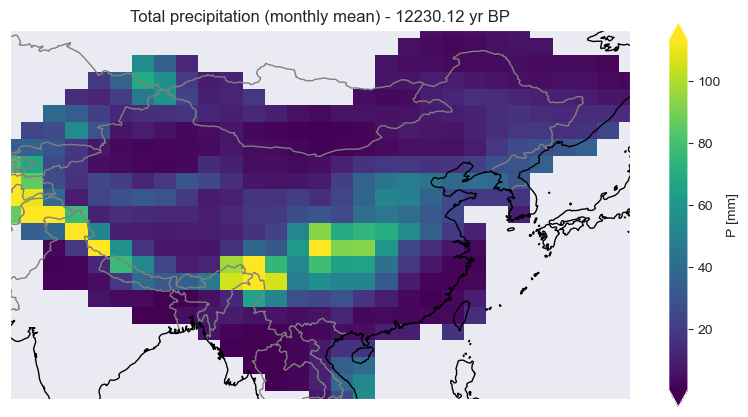

In [42]:
fig,ax = putils.plot_isoscape_latlon_platecarree(itrace_xrds.sel(time=time).P,time=f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',countries_borders=True,title='Total precipitation (monthly mean)',cbar_label='P [mm]') # type:ignore
plt.show() 
# Compute Variogram
# V = skg.Variogram(coords_proj, vals_s, n_lags=20, maxlag='median', model='spherical', use_nugget=True, normalize=False)
# ref_bins = V.bins
#
# df_prect=binned_prect_da.sel(time=time).to_dataframe(name='prect').reset_index().dropna(subset='prect') # type:ignore
# df_prect['lon']=utils.convert_lon_0_360_to_neg180_180(df_prect['lon'])

In [43]:
# df = pd.merge(df,df_prect,how='left',on=['lon','lat','time'])

In [44]:
df

,lon,lat,time,d18Op,P,x,y,elevation,dist_coast_m
2754,70.0,35.052631,193492.0,-13.585985,86.375931,7.792364e+06,4.171036e+06,3240.702232,1.101392e+06
2755,70.0,36.947369,193492.0,-15.434444,117.964622,7.792364e+06,4.431773e+06,956.879044,1.301563e+06
2756,70.0,38.842106,193492.0,-15.005886,112.095924,7.792364e+06,4.699080e+06,1543.150457,1.504516e+06
2757,70.0,40.736843,193492.0,-14.357686,79.645096,7.792364e+06,4.973603e+06,2164.049791,1.282587e+06
2758,70.0,42.631580,193492.0,-11.770010,33.793987,7.792364e+06,5.256062e+06,667.307993,1.275855e+06
...,...,...,...,...,...,...,...,...,...
5354,137.5,50.210526,193492.0,-29.741646,3.267816,1.530643e+07,6.482815e+06,128.535439,2.121262e+05
5355,137.5,52.105263,193492.0,-29.708921,2.241061,1.530643e+07,6.819181e+06,497.525743,1.585150e+05
5448,140.0,46.421051,193492.0,-18.534124,14.785440,1.558473e+07,5.848082e+06,0.000000,1.301880e+05
5449,140.0,48.315788,193492.0,-24.424076,6.453855,1.558473e+07,6.159552e+06,0.000000,7.365839e+02


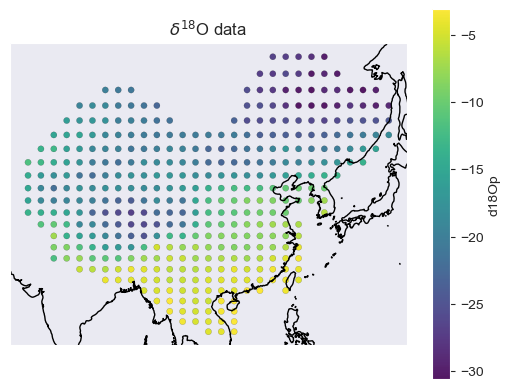

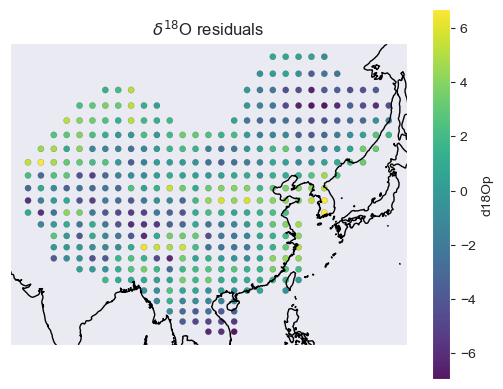

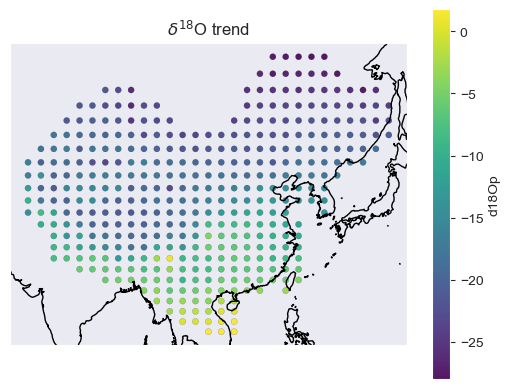

R2= 0.8538341064364618


,name,beta,std_error,p_value,vif,partial r2
0,intercept,11.136889,6.595744e-01,2.897822e-48,<NA>,<NA>
1,lat,-0.698425,1.806253e-02,1.196354e-134,3.734816,0.567633
2,elevation,-0.001943,1.170043e-04,4.471711e-47,2.194241,0.104661
3,dist_coast_m,0.000001,2.718377e-07,2.225443e-04,4.170458,0.005274
4,P,0.046878,5.534555e-03,5.240313e-16,1.601615,0.027237


In [45]:
detrended_df, results_dict = gutils.detrend_multiple_linear_regression(df, spec = 'lat_ele_D_P', D_col='dist_coast_m')


fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

res_df = gutils.multiple_linear_result_dict_to_df(result_dict=results_dict)
print('R2=',results_dict['r2'])

res_df

-> detrending with multiple linear regression, R2 is 0.854 detailed metrics are :
            name       beta     std_error        p_value       vif partial r2
0     intercept  11.136889  6.595744e-01   2.897822e-48      <NA>       <NA>
1         |lat|  -0.698425  1.806253e-02  1.196354e-134  3.734816   0.567633
2     elevation  -0.001943  1.170043e-04   4.471711e-47  2.194241   0.104661
3  dist_coast_m   0.000001  2.718377e-07   2.225443e-04  4.170458   0.005274
4             P   0.046878  5.534555e-03   5.240313e-16  1.601615   0.027237


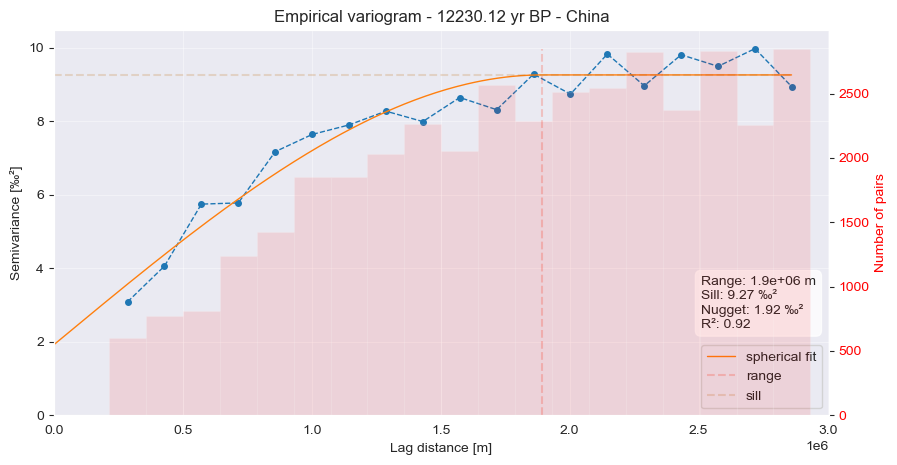

In [46]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multiple_linear_lat_abs_P_ele_D',
                                centers=ref_bins,
                                return_Variogram_object=True,
                                model='spherical')

parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP - China',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params=parameters_dict) #type:ignore
plt.show()